Analyzing result CSVs across different groups to detect any significant trends.

In [32]:
import sys
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from pathlib import Path
import optimal_alpha_csv_gen as opt
from constants import EVALUATED_COSTS_DIR
from scipy.stats import mannwhitneyu, wilcoxon

sns.set_theme(style="whitegrid")      # My recommendation
# or:
# sns.set_theme(style="ticks")
# sns.set_theme(style="darkgrid")

In [33]:
# Accessing data

df_treatment = pd.read_csv("data/metadata/metadata.csv")
df_results = pd.read_csv("data/results/heterogeneous_results/optimal_distance_values.csv")

df_treatment.columns = df_treatment.columns.str.strip()
df_results.columns = df_results.columns.str.strip()
# print(df_treatment.columns)
# print(df_results.columns)

df_treatment['arbor name'] = df_treatment['arbor name'].str.strip() # removing space in front of the arbor names from metadata.csv

# merging dataframes by arbor
combined_df = df_results.merge(df_treatment, left_on='arbor', right_on='arbor name', how='left')
# print(combined_df.head())
print(combined_df.head(10))

for i in range(150, 160):
    print(combined_df.loc[i, "hormone"])



                                               arbor     cost method    G  \
0  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
1  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
2  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
3  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
4  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
5  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
6  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
7  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
8  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
9  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   

   alpha  total squared orthogonal distance experiment  \
0   1.00                           0.914192   PimpiABA   
1   1.00                           0

In [7]:
print(len(df_results))
print(len(df_treatment))
print(len(combined_df))

4846
9795
4846


# Looking at the quantity of arbors that contrast in optimal alpha values belonging to each cost method

In [8]:
def extract_difference_values(arbor_folder):
    folder = Path(arbor_folder)

    alpha_diffs = []
    sq_orthog_dist_diffs = []
    for i, arbor_file in enumerate(folder.glob("*.csv")):
        
        homog_opt_info, heterog_opt_info, alpha_diff, sq_orthog_dist_diff = opt.extract_optimal_dist_vals(arbor_file, len(EVALUATED_COSTS_DIR))
        alpha_diffs.append(alpha_diff)
        sq_orthog_dist_diffs.append(sq_orthog_dist_diff)

    return alpha_diffs, sq_orthog_dist_diffs


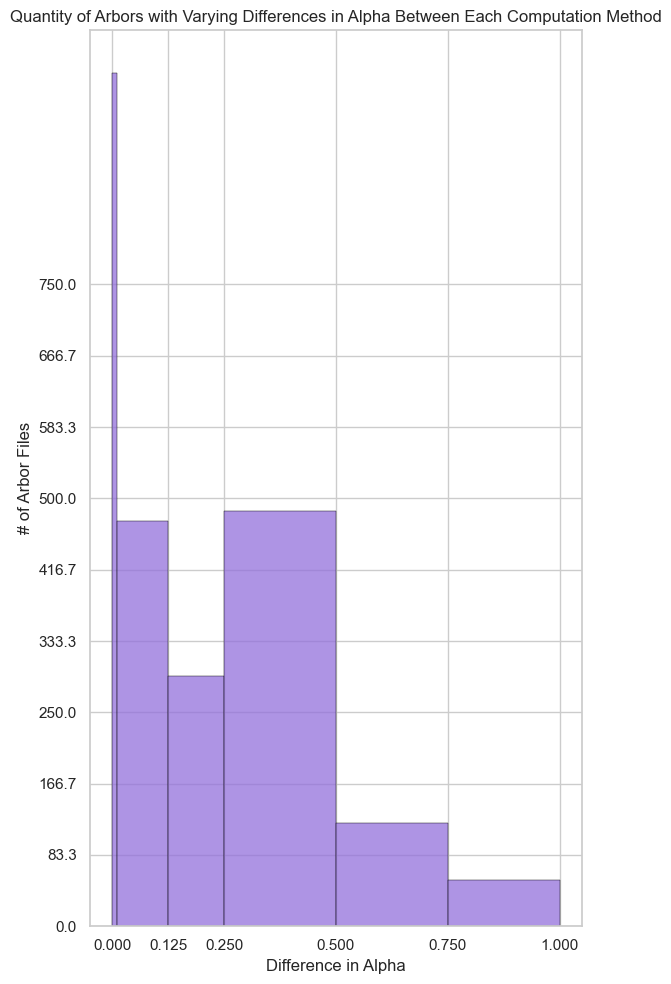

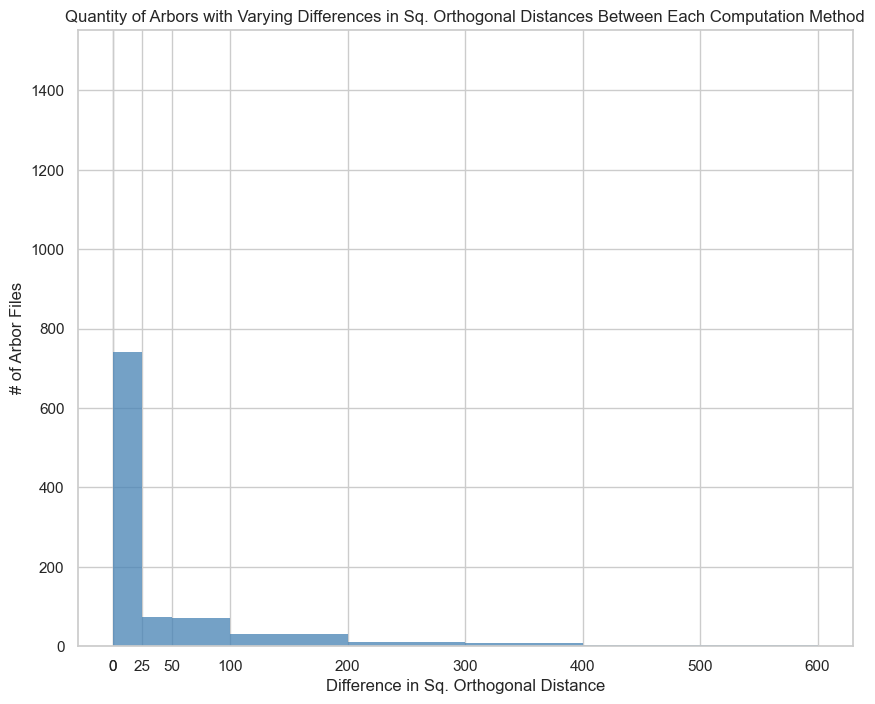

In [9]:
# Creating a histogram that categorizes values based on what range the difference in alpha (between each computation method) falls under

alpha_diffs, sq_orthog_dist_diffs = extract_difference_values(EVALUATED_COSTS_DIR)
plt.figure(figsize=(6, 10))

sns.histplot(alpha_diffs,
    bins=[0, .01, .125, 0.25, 0.5, 0.75, 1.0],
    color="mediumpurple",
    edgecolor="black",
    stat="count"
    )

plt.yticks(np.linspace(0, 750, 10))
plt.xticks([0, 0.125, 0.25, 0.5, 0.75, 1.0])
plt.xlabel("Difference in Alpha")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Alpha Between Each Computation Method")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

sns.histplot(
    sq_orthog_dist_diffs,
    bins=[0, .01, 25, 50, 100, 200, 300, 400, 500, 600],
    color="steelblue",
    edgecolor="black",
    stat="count"
)
plt.xticks([0, .01, 25, 50, 100, 200, 300, 400, 500, 600])
plt.xlabel("Difference in Sq. Orthogonal Distance")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Sq. Orthogonal Distances Between Each Computation Method")
plt.show()

# Looking at data by hormone treatment (histograms)


In [ ]:
# list of hormone treatmenets: no_hormone, no_ga, lo_ga, hi_ga, iaa, no_iaa, _10_aba, _1_aba, no_aba, hi_cyto, lo_cyto, no_cyto, 
# _5_acc, no_acc, _1_acc

In [23]:


def distribution_of_alpha_values_matplotlib(hormone, super_title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    #print(treatment_all)
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == ' homogeneous']
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == ' heterogeneous']

    ax[0].hist(treatment_all['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='purple', edgecolor='black')

    ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[0].set_title("Homogeneous and Heterogeneous", fontsize=16)

        # Homogeneous
    ax[1].hist(treatment_homogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='blue', edgecolor='black')

    ax[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[1].set_title("Homogeneous", fontsize=16)

        # Heterogeneous
    ax[2].hist(treatment_heterogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='red', edgecolor='black')

    ax[2].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[2].set_title("Heterogeneous", fontsize=16)

    fig.supxlabel("Optimal Alpha Values", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=16)

    plt.show()

def distribution_of_sq_orthog_dist_values_matplotlib(hormone, super_title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    #print(treatment_all)
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == ' homogeneous']
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == ' heterogeneous']

    ax[0].hist(treatment_all['total squared orthogonal distance'], color='green', edgecolor='black')

    #ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[0].set_title("Homogeneous and Heterogeneous", fontsize=16)

        # Homogeneous
    ax[1].hist(treatment_homogeneous['total squared orthogonal distance'], color='yellow', edgecolor='black')

    #ax[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[1].set_title("Homogeneous", fontsize=16)

        # Heterogeneous
    ax[2].hist(treatment_heterogeneous['total squared orthogonal distance'], color='blue', edgecolor='black')

    #ax[2].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[2].set_title("Heterogeneous", fontsize=16)

    fig.supxlabel("Optimal Alpha Values", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=16)

    plt.show()


# using seaborn
def distribution_of_alpha_values(hormone, super_title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == " homogeneous"]
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == " heterogeneous"]

    bins = [0, 0.25, 0.5, 0.75, 1.0]

    sns.histplot(data=treatment_all, x="alpha", bins=bins, color="purple", edgecolor="black", ax=ax[0])
    
    sns.histplot(
        data=treatment_homogeneous,
        x="alpha",
        bins=bins,
        color="royalblue",
        alpha=0.5,
        edgecolor="black",
        label="Homogeneous",
        ax=ax[1]
    )
    sns.histplot(
        data=treatment_heterogeneous,
        x="alpha",
        bins=bins,
        color="firebrick",
        alpha=0.5,
        edgecolor="black",
        label="Heterogeneous",
        ax=ax[1]
    )
    ax[1].legend(title="Cost Method")
    titles = ["Homogeneous and Heterogeneous Combined", "Homogeneous and Heterogeneous Seperate"]

    for axis, title in zip(ax, titles):
        axis.set_xticks(bins)
        axis.set_title(title, fontsize=16)
        
    fig.supxlabel("Optimal Alpha Value", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def distribution_of_sq_orthog_dist_value(hormone, super_title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == " homogeneous"]
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == " heterogeneous"]

    #bins = [0, 0.25, 0.5, 0.75, 1.0]

    #sns.histplot(data=treatment_all, x="total squared orthogonal distance", bins=bins, color="purple", edgecolor="black", ax=ax[0])
    sns.histplot(data=treatment_all, x="total squared orthogonal distance", color="purple", edgecolor="black", ax=ax[0])

    
    sns.histplot(
        data=treatment_homogeneous,
        #x="total squared orthogonal distance",
        #bins=bins,
        color="royalblue",
        alpha=0.5,
        edgecolor="black",
        ax=ax[1]
    )
    sns.histplot(
        data=treatment_heterogeneous,
        #x="total squared orthogonal distance",
        #bins=bins,
        color="firebrick",
        alpha=0.5,
        edgecolor="black",
        ax=ax[1]
    )
    titles = ["Homogeneous and Heterogeneous", "Homogeneous", "Heterogeneous"]

    for axis, title in zip(ax, titles):
        #axis.set_xticks(bins)
        axis.set_title(title, fontsize=16)
        
    fig.supxlabel("Total Squared Orthogonal Distance", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


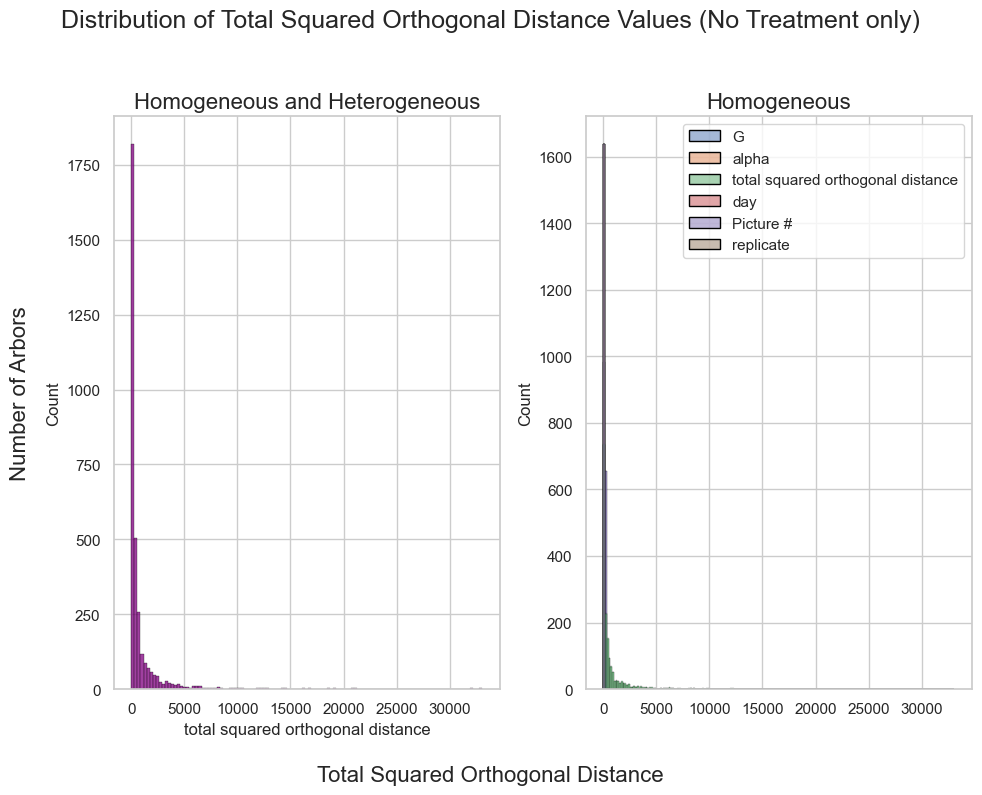

In [24]:
distribution_of_sq_orthog_dist_value([" None"], "Distribution of Total Squared Orthogonal Distance Values (No Treatment only)")

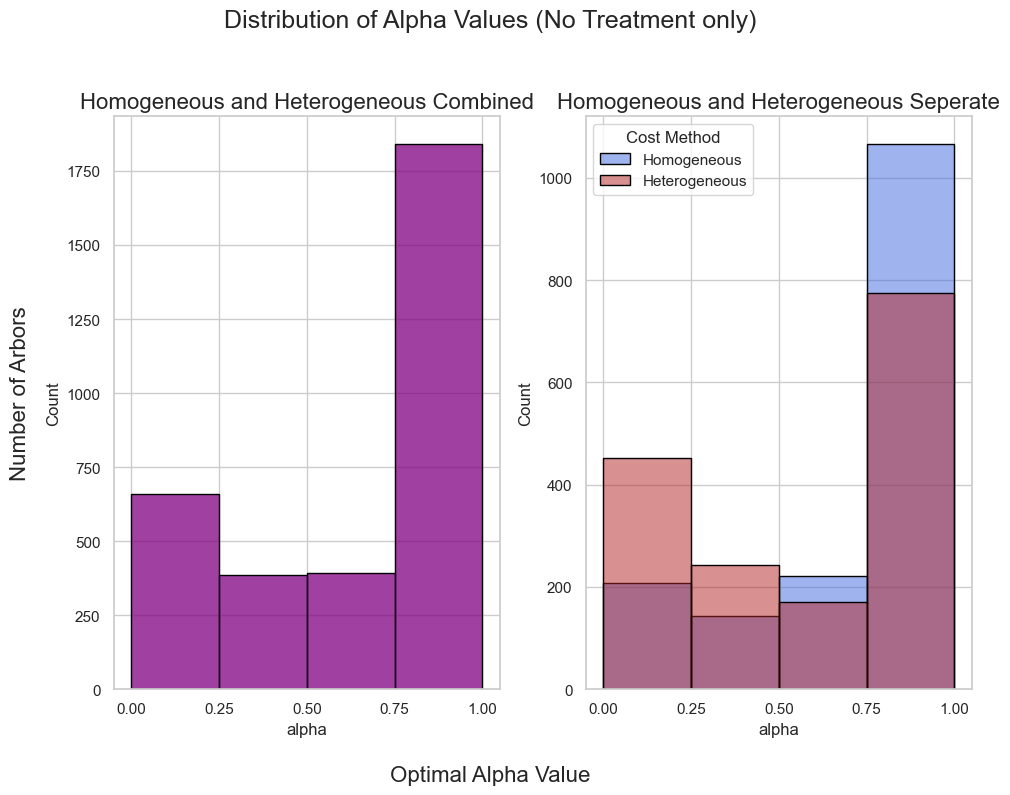

In [13]:
# Distribution of Alpha Values (No Treatment only)
distribution_of_alpha_values([" None"], "Distribution of Alpha Values (No Treatment only)")

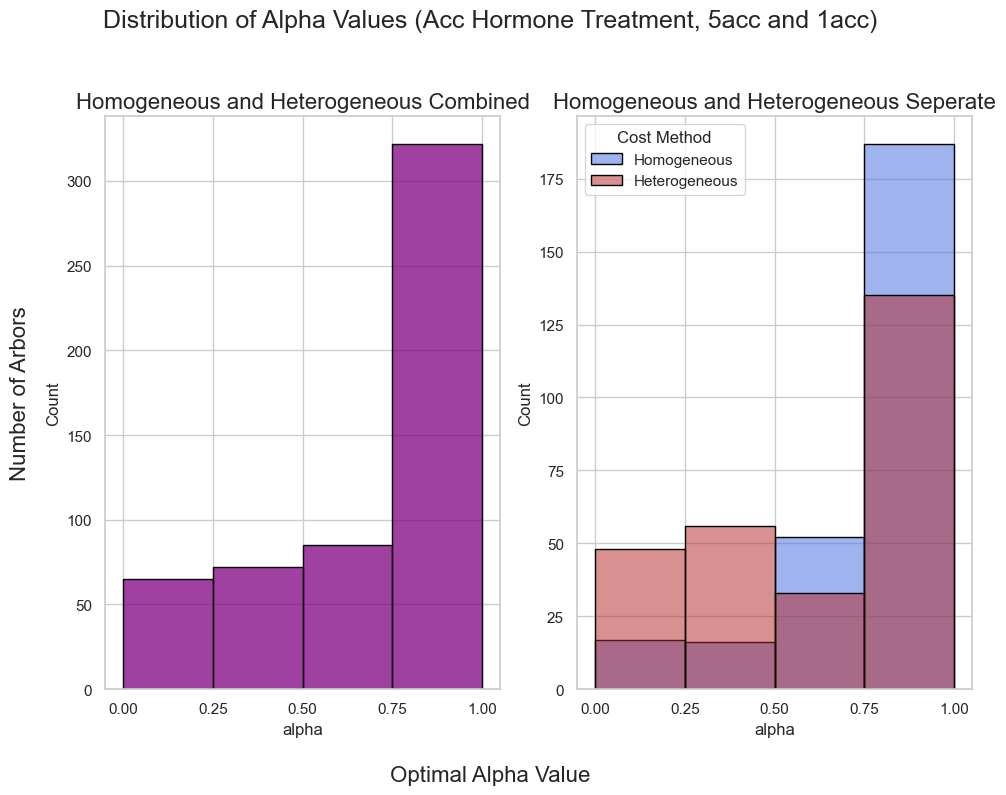

In [14]:
# Distribution of Alpha Values (No GA, No IAA, No ABA, No Cyto, No Acc) << TODO: Run again since this does not include all files yet (nothing is in the noiaa category)


distribution_of_alpha_values([" noga", " noiaa", " noaba", " nocyto", " noacc"], "Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)")


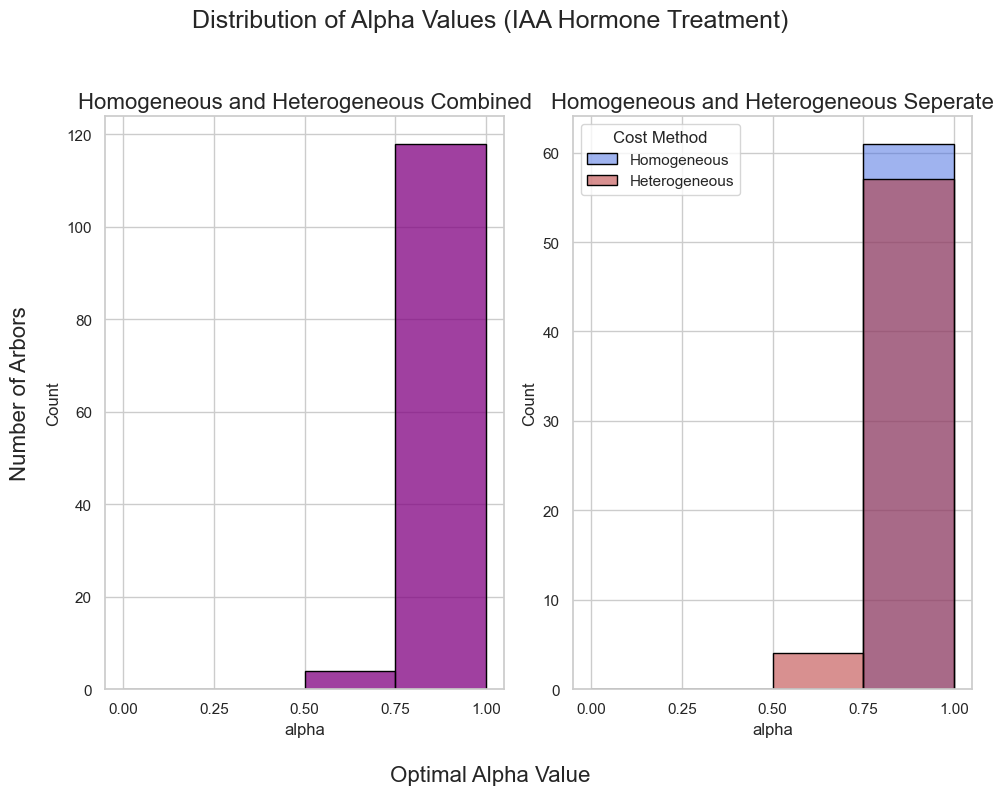

In [20]:
# Distribution of Alpha Values (IAA Hormone Treatment)
distribution_of_alpha_values([" iaa"], "Distribution of Alpha Values (IAA Hormone Treatment)")


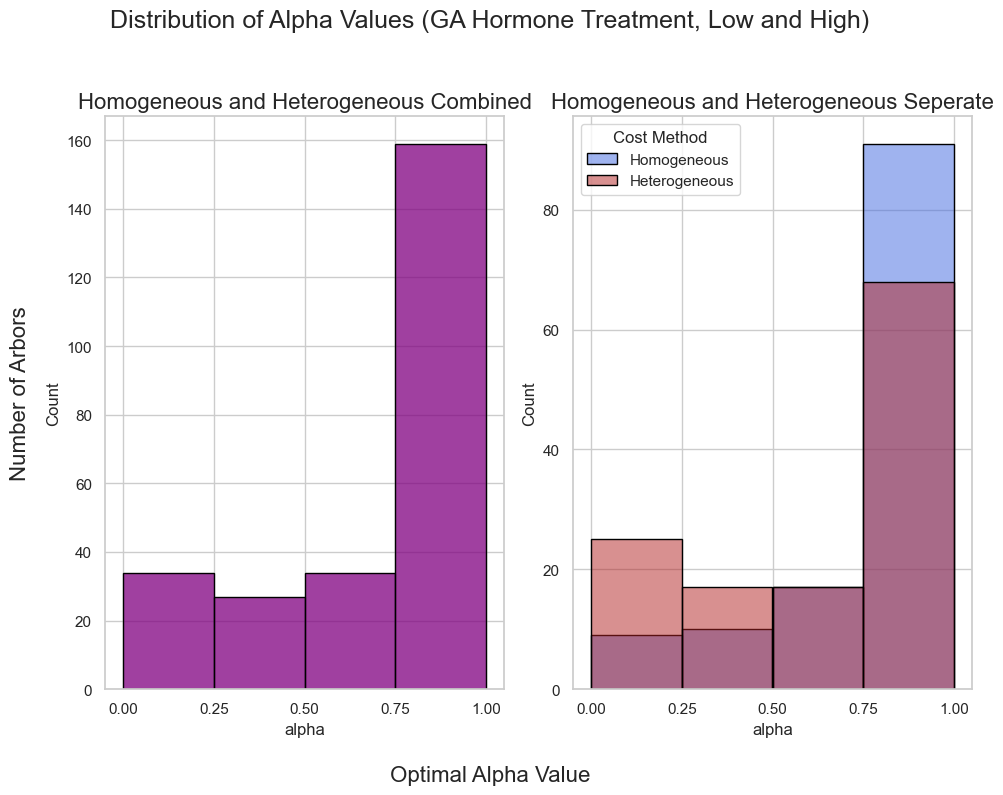

In [16]:
# Distribution of Alpha Values (GA Hormone Treatment, Low and High)
distribution_of_alpha_values([" loga", " higa"], "Distribution of Alpha Values (GA Hormone Treatment, Low and High)")

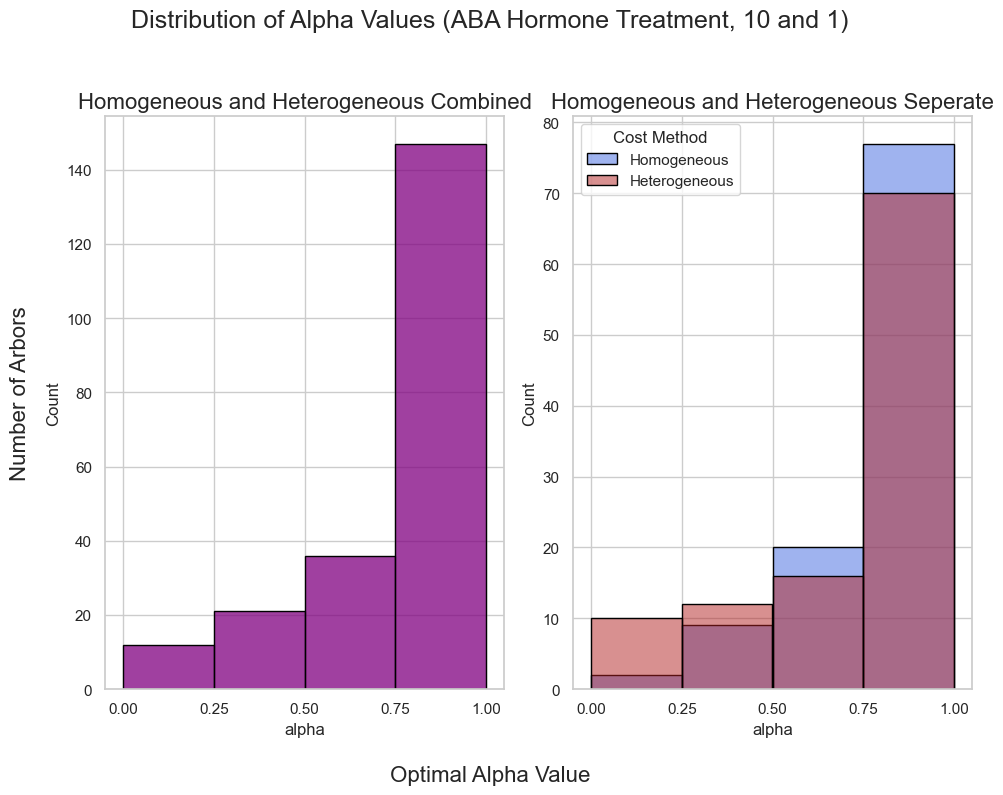

In [17]:
# Distribution of Alpha Values (ABA Hormone Treatment, 10 and 1)
distribution_of_alpha_values([" 10aba", " 1aba"], "Distribution of Alpha Values (ABA Hormone Treatment, 10 and 1)")

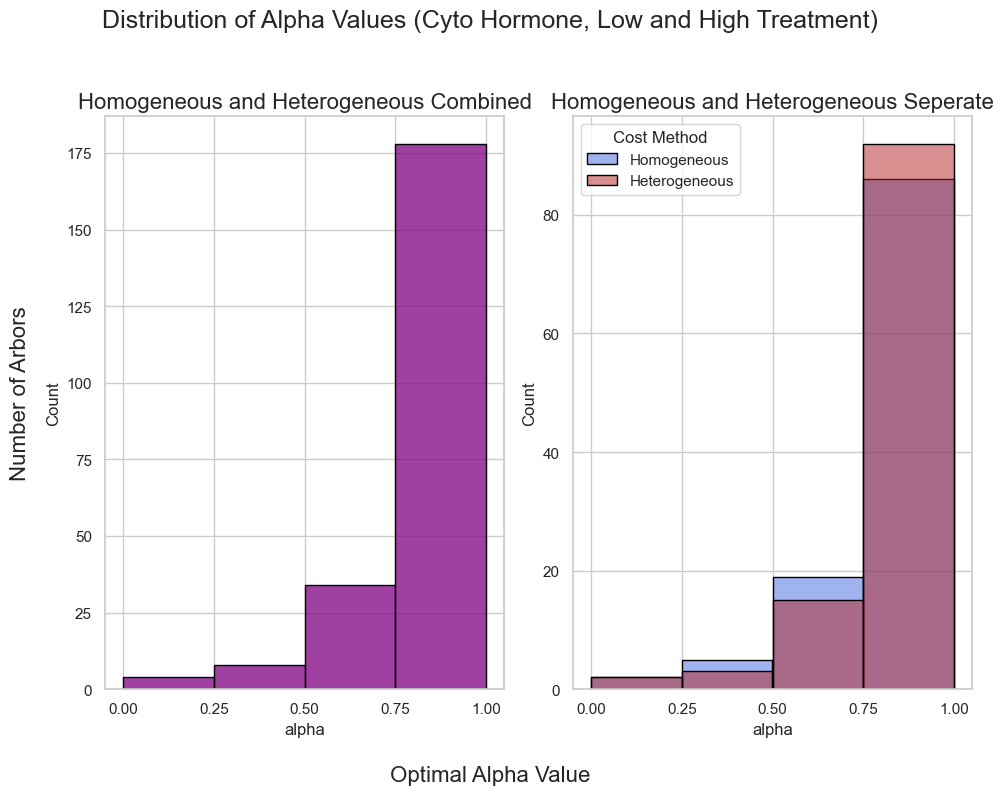

In [18]:
# Distribution of Alpha Values (Cyto Hormone, Low and High Treatment)
distribution_of_alpha_values([" hicyto", " locyto"], "Distribution of Alpha Values (Cyto Hormone, Low and High Treatment)")


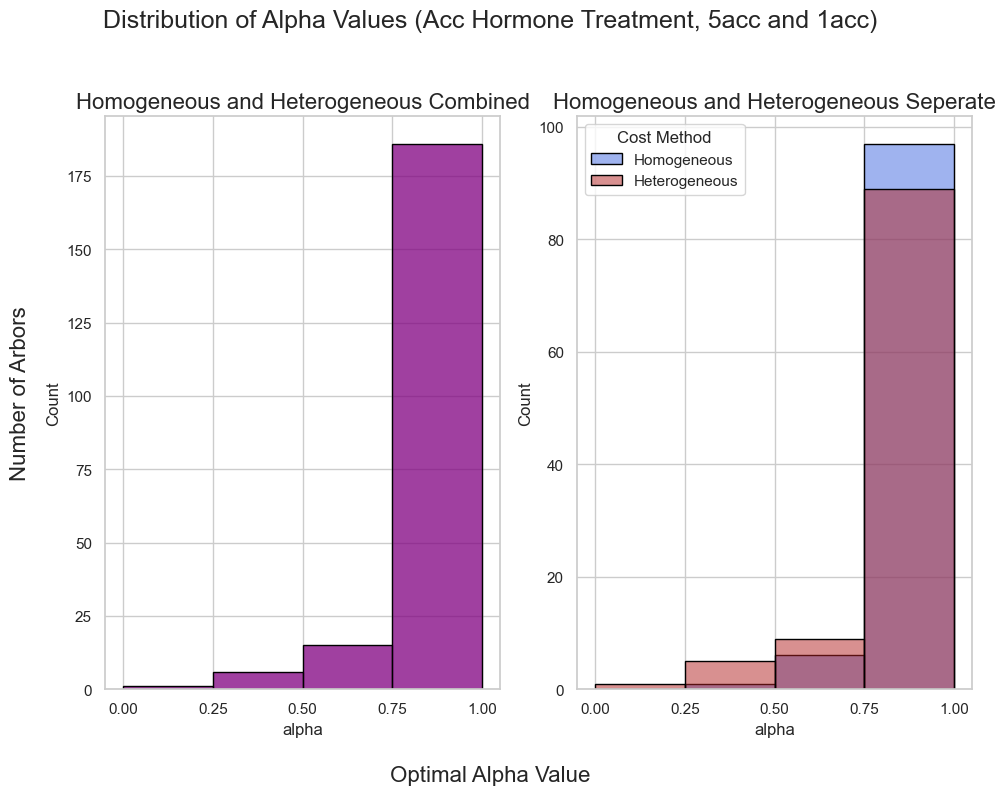

In [19]:
# Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)
distribution_of_alpha_values([" 5acc", " 1acc"], "Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)")


# Looking at data by hormone treatment (box plots)

In [35]:
#df_combined_ideotype_exc1 = df_combined_ideotype[df_combined_ideotype["ideotype (T/C/B)"].isin(['dT', 'T', 'C', 'B', 'CT', 'M', 'T/B', 'DT'])]

combined_df["hormone"] = combined_df["hormone"].str.strip()

fig = px.box(combined_df, x='hormone', y='alpha', color='hormone', points='all',
             title='Optimal Alpha Values by Hormone Treatment',
             category_orders={'hormone': ['10aba', '1aba', 'noaba', '5acc', '1acc', 'noacc', 'hicyto', 'locyto', 'nocyto',
                                          'higa', 'loga', 'noga', 'iaa', 'noiaa', 'None']}
             )

fig.show()

ABA

In [36]:
combined_df_aba = combined_df[combined_df["hormone"].isin(["10aba", "1aba", 'noaba'])]
fig = px.box(combined_df_aba, x='hormone', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Hormone Treatment and Cost Method',
             category_orders={'hormone': ['10aba', '1aba', 'noaba']}
             )

fig.show()

Acc

In [37]:
combined_df_acc = combined_df[combined_df["hormone"].isin(["5acc", "1acc", 'noacc'])]
fig = px.box(combined_df_acc, x='hormone', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Hormone Treatment and Cost Method',
             category_orders={'hormone': ['5acc', '1acc', 'noacc']}
             )

fig.show()

Cyto

In [38]:
combined_df_cyto = combined_df[combined_df["hormone"].isin(['hicyto', 'locyto', 'nocyto'])]
fig = px.box(combined_df_cyto, x='hormone', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Hormone Treatment and Cost Method',
             category_orders={'hormone': ['hicyto', 'locyto', 'nocyto']}
             )

fig.show()

GA

In [39]:
combined_df_ga = combined_df[combined_df["hormone"].isin(['higa', 'loga', 'noga'])]
fig = px.box(combined_df_ga, x='hormone', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Hormone Treatment and Cost Method',
             category_orders={'hormone': ['higa', 'loga', 'noga']}
             )

fig.show()

IAA

In [40]:
combined_df_iaa = combined_df[combined_df["hormone"].isin(['iaa', 'noiaa'])]
fig = px.box(combined_df_iaa, x='hormone', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Hormone Treatment and Cost Method',
             category_orders={'hormone': ['iaa', 'noiaa']}
             )

fig.show()

All "No Treatment" Groups

In [41]:
# graphing all relevant box plots
combined_df_none = combined_df[combined_df["hormone"].isin(['noaba', 'noacc', 'nocyto', 'noiaa', 'noga', 'None'])]
fig = px.box(combined_df_none, x='hormone', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Hormone Treatment and Cost Method',
             category_orders={'hormone': ['noaba', 'noacc', 'nocyto', 'noiaa', 'noga', 'None']}
             )

fig.show()

In [45]:
# combining all optimal alpha values and creating a box plot
fig = px.box(combined_df_none, x='cost method', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Cost Method (for all non-hormone treatments)',
             )

fig.show()

In [75]:
# combining all optimal alpha values and creating a box plot
fig = px.box(combined_df_none, y='alpha',  points='all',
             title='Optimal Alpha Values (for all non-hormone treatments)',
             )

fig.show()

In [50]:
# non-hormone treatments vs all hormone treatments
combined_df_hormone = combined_df[combined_df['hormone'].isin(['10aba', '1aba', '5acc', '1acc', 'hicyto', 'locyto',
                                                                'higa', 'loga', 'iaa'])]

fig = px.box(combined_df_hormone, x='cost method', y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Cost Method, Excluding Non-Hormone Treatments',
             )


fig.show()

In [ ]:
# combining all optimal alpha values and creating a box plot
fig = px.box(combined_df_none, y='alpha', color='cost method', points='all',
             title='Optimal Alpha Values by Cost Method (for all non-hormone treatments)',
             )

fig.show()

In [79]:
# Create copies so we don't modify the originals
combined_df_none = combined_df_none.copy()
combined_df_hormone = combined_df_hormone.copy()

# Add a new column identifying the treatment group
combined_df_none["Treatment Group"] = "No Hormone"
combined_df_hormone["Treatment Group"] = "Hormone"

# Combine the DataFrames
combined_df_compare = pd.concat(
    [combined_df_none, combined_df_hormone],
    ignore_index=True
)

# Remove leading/trailing spaces from the cost method labels (optional but recommended)
combined_df_compare["cost method"] = combined_df_compare["cost method"].str.strip()

fig = px.box(
    combined_df_compare,
    x="Treatment Group",
    y="alpha",
    color="cost method",
    points="all",
    title="Optimal Alpha Values by Cost Method, Comparing Hormone and Non-Hormone Treatments",
    category_orders={
        "Treatment Group": ["No Hormone", "Hormone"],
        "cost method": ["homogeneous", "heterogeneous"]
    },
    height=1000
)

fig.show()

In [43]:
# Creating a box plot combining all non-hormone treatments and comparing them to box plots of hormone treatment groups
combined_df_none_plot = combined_df_none.copy()

combined_df_none_plot['hormone'] = 'No Hormone' # creating a shared key 'No Hormone' to combine all non-treatment groups 

no_hormone_labels = ['noaba', 'noacc', 'nocyto', 'noiaa', 'noga', 'None']
combined_df_hormones = combined_df[~combined_df['hormone'].isin(no_hormone_labels)].copy() # excluding the non-hormone labels

combined_df_to_plot = pd.concat([combined_df_hormones, combined_df_none_plot], ignore_index=True) # combining the non-treatment and treatment groups into one dataframe (this time with 'No Hormone' label for non-treatment groups)

fig = px.box(combined_df_to_plot, x = 'hormone', y='alpha', color='hormone', points='all',
            title='Optimal Alpha Values Comparison Between Treatment and Non-Treatment Groups',
            category_orders={'hormone': ['10aba', '1aba', '5acc', '1acc', 'hicyto', 'locyto', 'higa', 'loga', 'iaa', 'No Hormone']},
            height=1000)

fig.show()

In [82]:
print(sorted(combined_df_to_plot["hormone"].unique()))

['10aba', '1aba', '1acc', '5acc', 'No Hormone', 'hicyto', 'higa', 'iaa', 'locyto', 'loga']


# Comparing optimal alpha values by ideotype (histograms)

In [6]:
# Accessing necessary data
#df_results = pd.read_csv("data/results/heterogeneous_results/optimal_distance_values.csv")

df_scoring = pd.read_csv("data\scoring-data\manual_scoring_last_day_fullname_ver.csv")
df_scoring["arbor name"] = df_scoring["arbor name"].str.strip()

matching = set(df_results['arbor']) and set(df_scoring['arbor name'])
print(f"# of matching arbors: {len(matching)}")



df_combined_ideotype = df_results.merge(df_scoring, left_on='arbor', right_on='arbor name', how='left', indicator=True)
print(df_combined_ideotype.head(10))

for i in range(2000, 2010):
    print(df_combined_ideotype.loc[i, 'ideotype (T/C/B)'])
    #print(df_combined_ideotype.loc[i, 'arbor'])
    #print(df_combined_ideotype.loc[i, 'arbor name'])
    



# of matching arbors: 6544
                                               arbor     cost method    G  \
0  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
1  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
2  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
3  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
4  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
5  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
6  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
7  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
8  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
9  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   

   alpha  total squared orthogonal distance arbor name  metadata day  \
0   1.00                           0.914192        Na

In [232]:
def distribution_of_alpha_by_ideotype(ideotype, super_title):
    """
    Creates two histograms of optimal alpha values for a given ideotype.

    Parameters
    ----------
    ideotype : str or list
        One ideotype (e.g. "T") or a list of ideotypes
        (e.g. ["T", "dT"]).

    super_title : str
        Figure title.
    """

    fig, ax = plt.subplots(1, 2, figsize=(10, 8))

    # Allow either a single ideotype or a list
    if isinstance(ideotype, str):
        ideotype = [ideotype]

    ideotype_all = df_combined_ideotype[df_combined_ideotype["ideotype (T/C/B)"].isin(ideotype)]

    ideotype_homogeneous = ideotype_all[ideotype_all["cost method"] == " homogeneous"]

    ideotype_heterogeneous = ideotype_all[ideotype_all["cost method"] == " heterogeneous"]

    bins = [0, 0.25, 0.5, 0.75, 1.0]

    # -----------------------------
    # Combined histogram
    # -----------------------------
    sns.histplot(
        data=ideotype_all,
        x="alpha",
        bins=bins,
        color="mediumpurple",
        edgecolor="black",
        stat="count",
        ax=ax[0]
    )

    ax[0].set_title("Combined Distribution")
    ax[0].set_xticks(bins)

    # -----------------------------
    # Overlay histogram
    # -----------------------------
    sns.histplot(
        data=ideotype_homogeneous,
        x="alpha",
        bins=bins,
        color="royalblue",
        alpha=0.5,
        edgecolor="black",
        stat="count",
        label="Homogeneous",
        ax=ax[1]
    )

    sns.histplot(
        data=ideotype_heterogeneous,
        x="alpha",
        bins=bins,
        color="firebrick",
        alpha=0.5,
        edgecolor="black",
        stat="count",
        label="Heterogeneous",
        ax=ax[1]
    )

    ax[1].set_title("Homogeneous vs. Heterogeneous")
    ax[1].set_xticks(bins)
    ax[1].legend(title="Cost Method")

    fig.supxlabel("Optimal Alpha", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

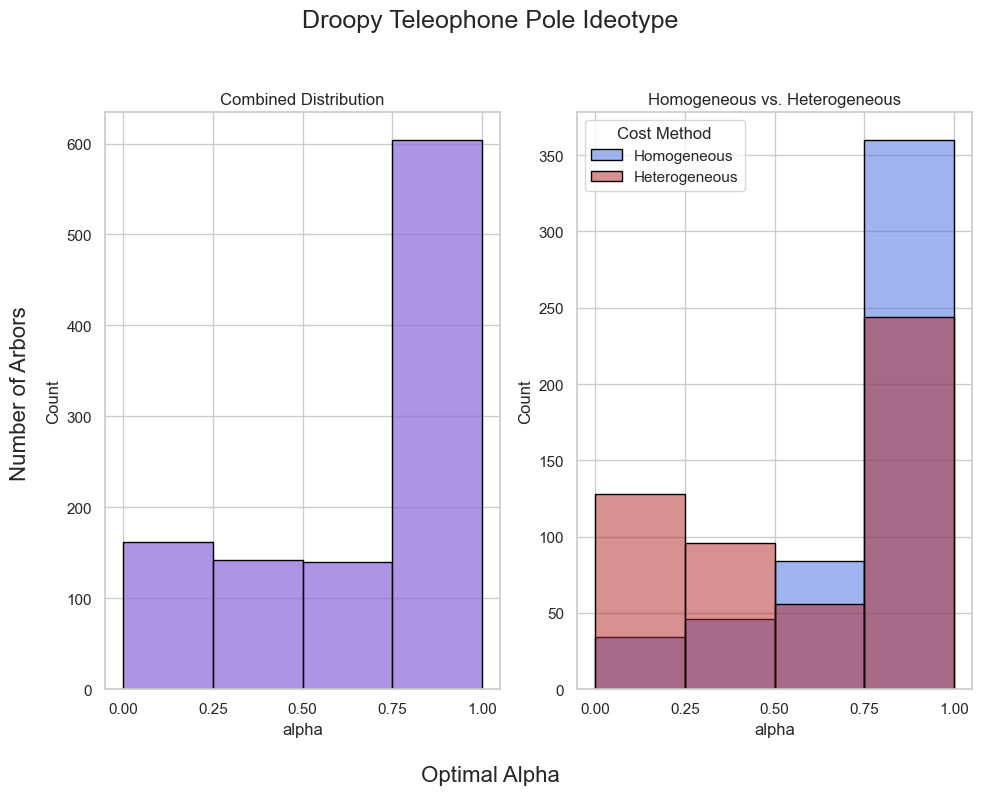

In [233]:
distribution_of_alpha_by_ideotype("dT", "Droopy Teleophone Pole Ideotype")

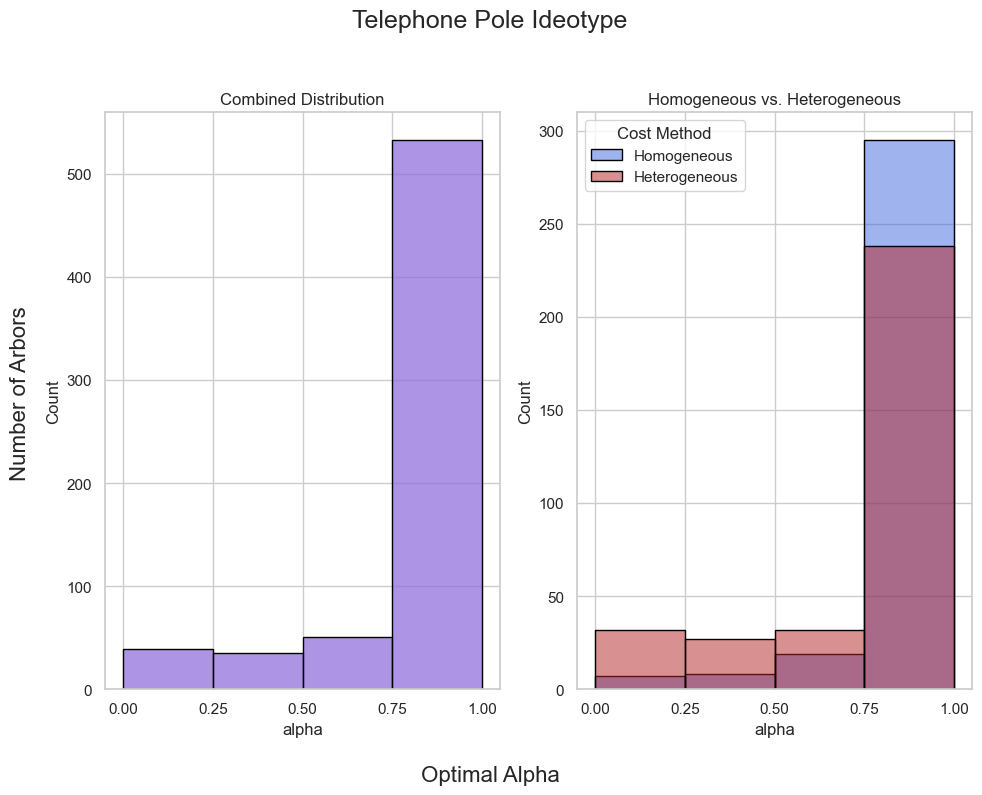

In [234]:
distribution_of_alpha_by_ideotype("T", "Telephone Pole Ideotype")

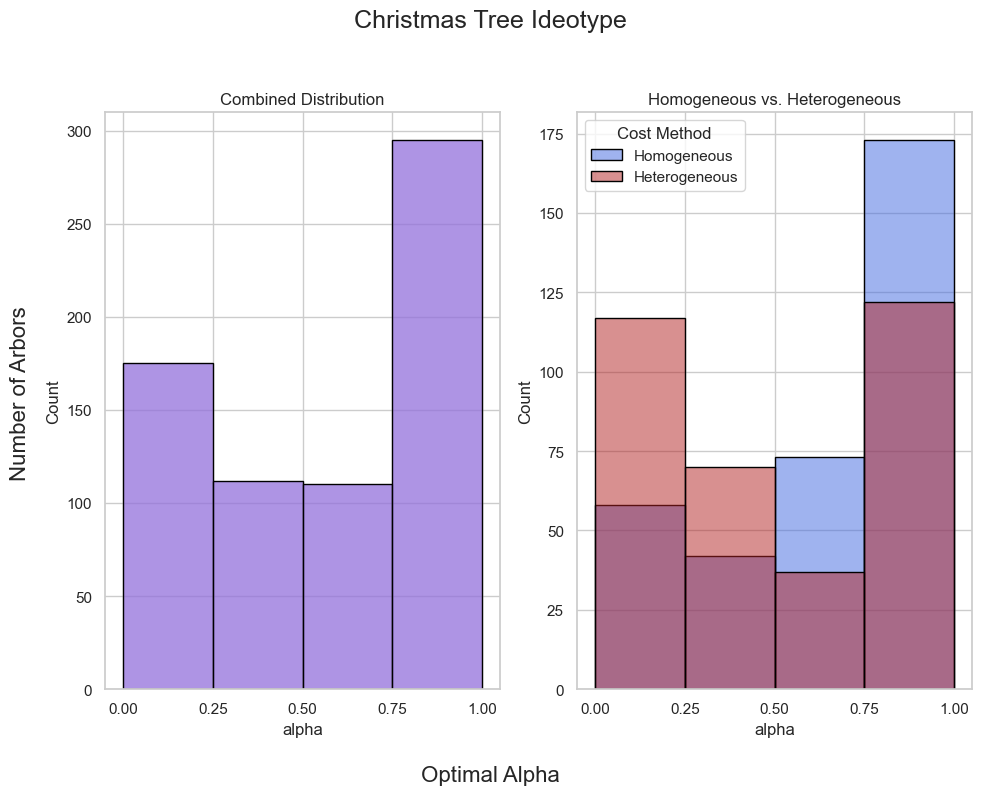

In [235]:
distribution_of_alpha_by_ideotype("C", "Christmas Tree Ideotype")

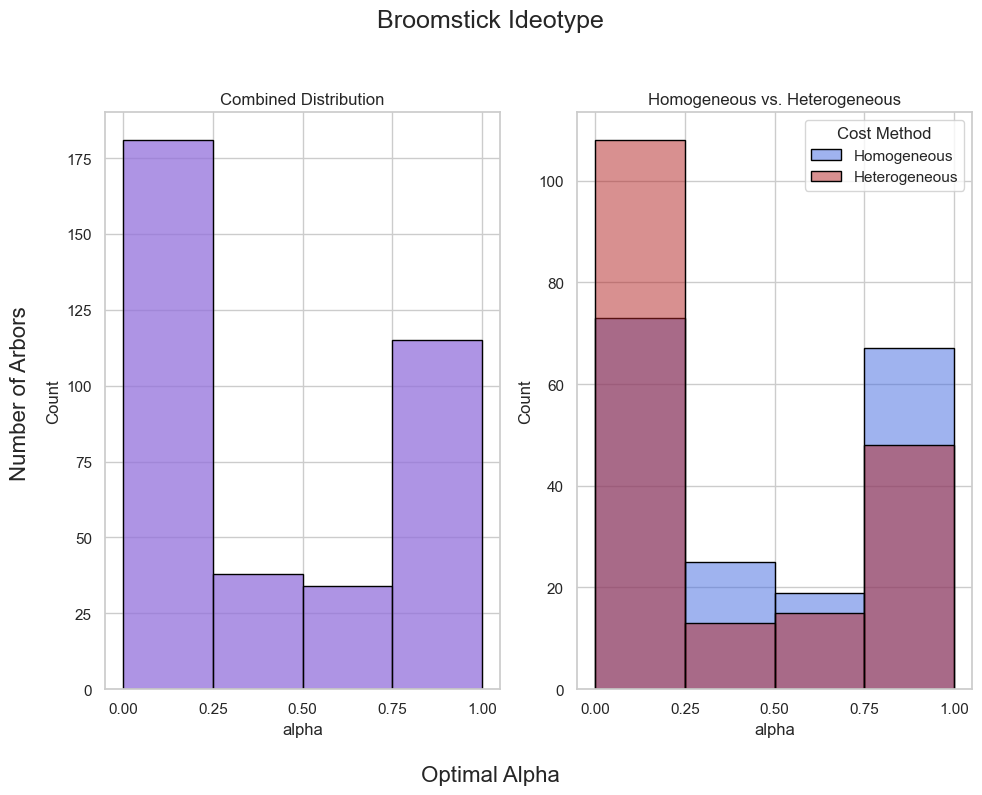

In [236]:
distribution_of_alpha_by_ideotype("B", "Broomstick Ideotype")

# Comparing optimal alpha values by ideotype (boxplots)

In [56]:
df_combined_ideotype_exc1 = df_combined_ideotype[df_combined_ideotype["ideotype (T/C/B)"].isin(['dT', 'T', 'C', 'B', 'CT', 'M', 'T/B', 'DT'])]

fig = px.box(df_combined_ideotype_exc1, x='ideotype (T/C/B)', y='alpha', color='ideotype (T/C/B)', points='all', 
             title='Distribution of Optimal Alpha Values for All Ideotypes Recorded',
             category_orders={"ideotype (T/C/B)": ['dT', 'T', 'C', 'B', 'CT', 'M', 'T/B', 'DT']})

fig.update_layout(xaxis_title='Ideotype', yaxis_title='Optimal Alpha', showlegend=True,
                  height=800)
#fig.update_traces(
 #   jitter=0.35,
 #   pointpos=0
#)

fig.show()

In [57]:
# filtering out unwanted ideotype categories (specifically M, T/B, and '?')
dT_df = df_combined_ideotype[df_combined_ideotype["ideotype (T/C/B)"].isin(['dT', 'DT'])]
t_df = df_combined_ideotype[df_combined_ideotype['ideotype (T/C/B)'] == 'T']
c_df = df_combined_ideotype[df_combined_ideotype['ideotype (T/C/B)'].isin(['C', 'CT'])]
b_df = df_combined_ideotype[df_combined_ideotype['ideotype (T/C/B)'] == 'B']

df_combined_ideotype_exc2 = pd.concat([dT_df, t_df, c_df, b_df], ignore_index=True)


# standardizing labels for christmas tree nad droopy telephone
df_combined_ideotype_exc2['ideotype (T/C/B)'] = (df_combined_ideotype_exc2['ideotype (T/C/B)']
                                                 .replace({
                                                     'DT':'dT',
                                                     'CT':'C'
                                                 }))
#df_combined_ideotype_exc2 = df_combined_ideotype[df_combined_ideotype["ideotype (T/C/B)"].isin(['dT', 'T', 'C', 'B'])]
fig = px.box(df_combined_ideotype_exc2, x='ideotype (T/C/B)', y='alpha', color='ideotype (T/C/B)', points='all', 
             title='Distribution of Optimal Alpha Values for Only Droopy Telephone, Telephone, Christmas Tree, and Broomstick',
             category_orders={"ideotype (T/C/B)": ['dT', 'T', 'C', 'B']})

fig.update_layout(xaxis_title='Ideotype', yaxis_title='Optimal Alpha', showlegend=True,
                  height=800)
fig.show()

In [59]:

fig = px.box(df_combined_ideotype_exc2, x='ideotype (T/C/B)', y='alpha', color='cost method', points='all', 
             category_orders={'Ideotype (T/C/B)': ['dT', 'T', 'C', 'B'],
             'cost method': [' homogeneous', 'heterogeneous']},
             title='Optimal Alpha Values by Ideotype and Cost Method')
#fig = px.box(dT_df, x='cost method', y='alpha', color='cost method', points='all', title='Optimal Alpha Values for Droopy Telephone Ideotype')
fig.update_layout(xaxis_title='Ideotype', yaxis_title='Optimal Alpha', showlegend=True,
                  height=800, boxgroupgap=0.4)
fig.show()

# Comparing optimal alpha values for Salt vs. Control conditions 

In [21]:
# combine metadata.csv () and optimal_distance_values.csv and manual_scoring_last_day_fullname_ver to make it so optimal alpha value, condition, and ideotype is all in one place
# df_results (optimal_distance_values.csv), df_treatment (metadata.csv), df_scoring (manual_scoring_last_day_fullname_ver.csv)
# df_combined_ideotype is df_results + df_scoring
# df_combined_ideotype_and_metadata = df_combined_ideotype + df_treatment

df_combined_ideotype_and_metadata = df_combined_ideotype.merge(df_treatment, left_on='arbor', right_on='arbor name', how='left')
print(df_combined_ideotype_and_metadata.head(1))

for i in range(100, 110):
    print(df_combined_ideotype_and_metadata.loc[i, 'ideotype (T/C/B)'])
    #print(df_combined_ideotype.loc[i, 'arbor'])
    #print(df_combined_ideotype.loc[i, 'arbor name'])



                                               arbor   cost method    G  \
0  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   homogeneous  0.0   

   alpha  total squared orthogonal distance arbor name_x  metadata day  \
0    1.0                           0.914192          NaN           NaN   

  ideotype (T/C/B) size (L/M/S) Sodium gap?  ... metadata match?     _merge  \
0              NaN          NaN         NaN  ...             NaN  left_only   

  experiment                                       arbor name_y day Picture #  \
0   PimpiABA  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   9         1   

   genotype  replicate condition  hormone  
0      M248         10         C    10aba  

[1 rows x 22 columns]
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [61]:
df_combined_ideotype_and_metadata['condition'] = (
    df_combined_ideotype_and_metadata['condition'].str.strip()
    )

df_combined_ideotype_and_metadata['condition'] = (df_combined_ideotype_and_metadata['condition']
                                                 .replace({
                                                     's':'S',
                                                     'c':'C'
                                                 }))

fig = px.box(df_combined_ideotype_and_metadata, x='condition', y='alpha', color='condition', points='all', 
             height=1000,
             category_orders={'condition': ['C', 'S'],
             'cost method': [' homogeneous', 'heterogeneous']},
             title='Optimal Alpha Values by Condition')
#fig = px.box(dT_df, x='cost method', y='alpha', color='cost method', points='all', title='Optimal Alpha Values for Droopy Telephone Ideotype')

fig.update_xaxes(
    tickvals=["C", "S"],
    ticktext=["Control", "Salt"]
)

fig.update_layout(xaxis_title='Condition', yaxis_title='Optimal Alpha')
fig.show()

Optimal alpha values are more distributed in arbors that were assigned to the Salt condition compared to the arbors assigned to the control condition. 

In [62]:
fig = px.box(df_combined_ideotype_and_metadata, x='condition', y='alpha', color='cost method', points='all',
             height=700, 
             category_orders={'condition': ['C', 'S'],
             'cost method': [' homogeneous', 'heterogeneous']},
             title='Optimal Alpha Values by Condition and Cost Method')
#fig = px.box(dT_df, x='cost method', y='alpha', color='cost method', points='all', title='Optimal Alpha Values for Droopy Telephone Ideotype')

fig.update_layout(
    xaxis_title='Condition', yaxis_title='Optimal Alpha',
    boxmode='group',
    boxgroupgap=0.4
)

fig.update_xaxes(
    tickvals=["C", "S"],
    ticktext=["Control", "Salt"]
)
fig.show()

**Distribution of ideotype optimal alpha values (OAVs) by condition**

In [ ]:
# dealing with mismatching labels for christmas tree nad droopy telephone
df_combined_ideotype_and_metadata['ideotype (T/C/B)'] = (df_combined_ideotype_and_metadata['ideotype (T/C/B)']
                                                 .replace({
                                                     'DT':'dT',
                                                     'CT':'C'
                                                 }))


# filtering out unwanted ideotype categories (specifically M, T/B, and '?')
dT_df = df_combined_ideotype_and_metadata[df_combined_ideotype_and_metadata["ideotype (T/C/B)"] == 'dT']
t_df = df_combined_ideotype_and_metadata[df_combined_ideotype_and_metadata['ideotype (T/C/B)'] == 'T']
c_df = df_combined_ideotype_and_metadata[df_combined_ideotype_and_metadata['ideotype (T/C/B)'] == 'C']
b_df = df_combined_ideotype_and_metadata[df_combined_ideotype_and_metadata['ideotype (T/C/B)'] == 'B']

df_combined_ideotype_and_metadata = pd.concat([dT_df, t_df, c_df, b_df], ignore_index=True)

df_combined_ideotype_and_metadata['condition'] = (df_combined_ideotype_and_metadata['condition']
                                                .replace({
                                                    ' s':'S',
                                                    ' c':'C',
                                                    ' C': 'C',
                                                    ' S': 'S'
                                                }))



fig = px.box(df_combined_ideotype_and_metadata, x='ideotype (T/C/B)', y='alpha', color='condition',
       title = 'OAVs by Ideotype and Condition'

)
fig.show()

# printing number of arbors that fall under a certain condition and a certain ideotype category
print(len(df_combined_ideotype_and_metadata[(df_combined_ideotype_and_metadata['condition'] == 'C') & (df_combined_ideotype_and_metadata['ideotype (T/C/B)'] == 'T')]))

518


Distribution of ideotype OAVs by condition widely varies when focusing within ideotypes and comparing between condition groups. 

**Distribution of hormone OAVs by condition** 

In [ ]:

combined_df_to_plot['condition'] = (combined_df_to_plot['condition']
                                    .replace({
                                        ' s':'S',
                                        ' c':'C',
                                        ' C': 'C',
                                        ' S': 'S'
                                    }))
fig = px.box(combined_df_to_plot, x = 'hormone', y='alpha', color='condition', points='all',
            title='Optimal Alpha Values Comparison Between Treatment and Non-Treatment Groups',
            category_orders={'hormone': ['10aba', '1aba', '5acc', '1acc', 'hicyto', 'locyto', 'higa', 'loga', 'iaa', 'No Hormone']},
            height=1000)

fig.show()

A majority of the OAV distributions by each hormone treatment are wider in the salt condition than they are in the 

# Statistical Analysis

Seeing if distribution of optimal alpha values are significantly different across Salt vs. Control conditions

In [ ]:

print(f"Mann-Whitney U Test (for independent samples)")
print(f"    --- Comparing optimal alphas (Conditions) ---")

salt_alphas = df_combined_ideotype_and_metadata.loc[df_combined_ideotype_and_metadata['condition'] == ' S', 'alpha']
control_alphas = df_combined_ideotype_and_metadata.loc[df_combined_ideotype_and_metadata['condition'] == ' C', 'alpha']
#print(f'Control alphas: {control_alphas}')
#print(f'Salt alphas: {salt_alphas}')
# TODO: Check why there are MORE CONTROL ARBOR ALPHA VALUES than there are salt arbor alpha values 

# wilcoxon test


# mann-whitney test << using mann-whitney since there are mismatching amounts of control and salt arbors
statistic, p_value = mannwhitneyu(control_alphas, salt_alphas, alternative='two-sided')

print(f"    Salt vs. Control --> Statistic: {statistic} | P-value: {p_value}")
print(f"    Homogeneous vs. Heterogeneous Cost Method (Within Salt Condition) --> ")
print(f"    Homogeneous vs. Heterogeneous Cost Method (Within Control Condition) --> ")

print(f"    --- Comparing optimal alphas (Ideotypes) ---")

print(f"    Homogeneous vs. Heterogeneous Cost Method (Within Salt Condition) --> ")



Mann-Whitney U Test (for independent samples)
    --- Comparing optimal alphas ---
    Salt vs. Control --> Statistic: 4149325.0 | P-value: 7.634469744834235e-152
